In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import time
import pandas as pd

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Input, Lambda, GlobalAveragePooling2D, Dense, Dropout,
                                      Conv2D, AveragePooling2D, MaxPooling2D, Flatten,
                                      BatchNormalization)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.environ['KERAS_HOME'] = '/content/drive/MyDrive/keras_cache'
os.makedirs(os.environ['KERAS_HOME'], exist_ok=True)

Mounted at /content/drive


In [3]:
# 1. Load CIFAR-10
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

print("Full training data shape:", x_train_full.shape)
print("Full training labels shape:", y_train_full.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1417s 8us/step
Full training data shape: (50000, 32, 32, 3)
Full training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


In [4]:
# Proper train / validation split: carve 5,000 images OUT of the training set for validation.
# The test set (x_test/y_test, 10,000 images) is held out completely and only used
# for final evaluation in Task 5 -- never seen during training or EarlyStopping.
from sklearn.model_selection import train_test_split

VAL_SIZE = 5000

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=VAL_SIZE,
    random_state=42,
    stratify=y_train_full   # keeps class balance equal across the split
)

# 4. Print dimensions
print("Training data shape:  ", x_train.shape)
print("Validation data shape:", x_val.shape)
print("Testing data shape:   ", x_test.shape)

Training data shape:   (45000, 32, 32, 3)
Validation data shape: (5000, 32, 32, 3)
Testing data shape:    (10000, 32, 32, 3)


In [5]:
# 2. Normalize pixel values to the range [0,1]
x_train = x_train.astype('float32') / 255.0
x_val   = x_val.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# One-hot encode labels
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

y_true = y_test.flatten()   # plain integer labels for the test set, used later for metrics

/tmp/ipykernel_1355/722349596.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


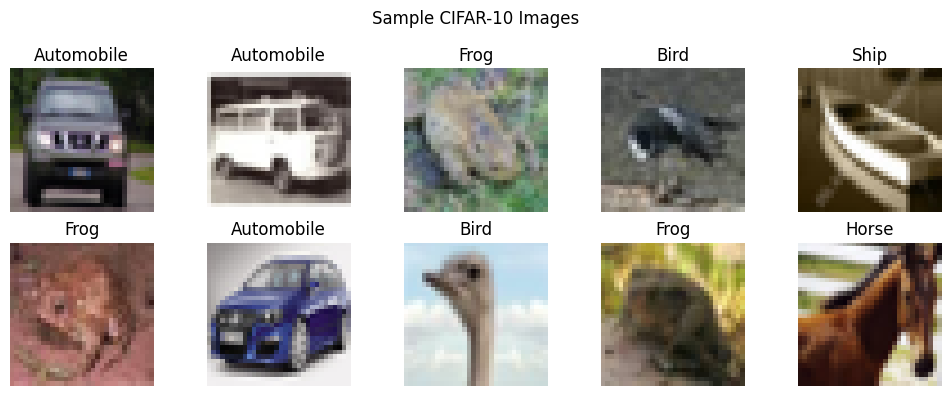

In [6]:
# 3. Display ten sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()

In [7]:
BASE_MODEL_NAME = "VGG16"   # change to "ResNet50", "MobileNetV2", "InceptionV3", or "EfficientNetB0"
IMG_SIZE = 96                 # resized input (keeps things fast on Colab)

def get_base_model(name, input_shape):
    if name == "VGG16":
        from tensorflow.keras.applications import VGG16
        from tensorflow.keras.applications.vgg16 import preprocess_input
        base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif name == "ResNet50":
        from tensorflow.keras.applications import ResNet50
        from tensorflow.keras.applications.resnet50 import preprocess_input
        base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    elif name == "MobileNetV2":
        from tensorflow.keras.applications import MobileNetV2
        from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
        base = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    elif name == "InceptionV3":   # closest available equivalent to GoogleNet (its direct successor)
        from tensorflow.keras.applications import InceptionV3
        from tensorflow.keras.applications.inception_v3 import preprocess_input
        base = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    elif name == "EfficientNetB0":
        from tensorflow.keras.applications import EfficientNetB0
        from tensorflow.keras.applications.efficientnet import preprocess_input
        base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError("Unknown base model: " + name)
    return base, preprocess_input

base_model, preprocess_input = get_base_model(BASE_MODEL_NAME, (IMG_SIZE, IMG_SIZE, 3))

# 3. Freeze the convolutional base
base_model.trainable = False

print(f"Loaded {BASE_MODEL_NAME} with {base_model.count_params():,} parameters (frozen)")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loaded VGG16 with 14,714,688 parameters (frozen)


In [8]:
# Build the full model: resize -> undo [0,1] scaling -> preprocess -> pretrained base -> GAP -> Dense -> Softmax
inputs = Input(shape=(32, 32, 3))
x = Lambda(lambda img: tf.image.resize(img, (IMG_SIZE, IMG_SIZE)))(inputs)
x = Lambda(lambda img: img * 255.0)(x)      # x_train/x_val/x_test stay in [0,1]; this un-scales
x = Lambda(preprocess_input)(x)              # only for the pretrained model's expected input range
x = base_model(x, training=False)

# 4. Global Average Pooling layer
x = GlobalAveragePooling2D()(x)

# 5. Dense layer with ReLU activation
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

# 6. Output layer with Softmax activation
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
BATCH_SIZE = 32
EPOCHS = 15

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history = model.fit(
    x_train, y_train_cat,
    validation_data=(x_val, y_val_cat),     # validation split, NOT the test set
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.7336 - loss: 0.9160 - val_accuracy: 0.8084 - val_loss: 0.5479
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 48ms/step - accuracy: 0.8112 - loss: 0.5552 - val_accuracy: 0.8306 - val_loss: 0.5120
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 48ms/step - accuracy: 0.8341 - loss: 0.4846 - val_accuracy: 0.8282 - val_loss: 0.5286
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 49ms/step - accuracy: 0.8429 - loss: 0.4537 - val_accuracy: 0.8258 - val_loss: 0.5452
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 48ms/step - accuracy: 0.8544 - loss: 0.4185 - val_accuracy: 0.8318 - val_loss: 0.5134
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 48ms/step - accuracy: 0.8670 - loss: 0.3806 - val_accuracy: 0.8358 - val_loss: 0.5355


In [10]:
# Accuracy on the held-out TEST set before fine tuning
pre_ft_loss, pre_ft_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Pre-fine-tuning Test Accuracy: {pre_ft_acc*100:.2f}%")

Pre-fine-tuning Test Accuracy: 81.36%


In [11]:

# 1. Unfreeze the last convolutional block
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.8)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [12]:
# 2. Train for another 5-10 epochs (still validating on x_val, not the test set)
FT_EPOCHS = 8

history_ft = model.fit(
    x_train, y_train_cat,
    validation_data=(x_val, y_val_cat),
    batch_size=BATCH_SIZE,
    epochs=FT_EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 108s 71ms/step - accuracy: 0.8683 - loss: 0.3788 - val_accuracy: 0.8754 - val_loss: 0.3714
Epoch 2/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 93s 66ms/step - accuracy: 0.9188 - loss: 0.2338 - val_accuracy: 0.8894 - val_loss: 0.3435
Epoch 3/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 92s 66ms/step - accuracy: 0.9423 - loss: 0.1623 - val_accuracy: 0.8998 - val_loss: 0.3372
Epoch 4/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 92s 66ms/step - accuracy: 0.9614 - loss: 0.1123 - val_accuracy: 0.8996 - val_loss: 0.3488
Epoch 5/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 92s 66ms/step - accuracy: 0.9733 - loss: 0.0770 - val_accuracy: 0.9118 - val_loss: 0.3440
Epoch 6/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 92s 66ms/step - accuracy: 0.9810 - loss: 0.0574 - val_accuracy: 0.9056 - val_loss: 0.3563
Epoch 7/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 92s 66ms/step - accuracy: 0.9868 - loss: 0.0426 - val_accuracy: 0.9062 - val_loss: 0.3914


In [13]:
# 3. Compare TEST accuracy before and after fine tuning
post_ft_loss, post_ft_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Pre-fine-tuning  Test Accuracy: {pre_ft_acc*100:.2f}%")
print(f"Post-fine-tuning Test Accuracy: {post_ft_acc*100:.2f}%")
print(f"Improvement: {(post_ft_acc - pre_ft_acc)*100:.2f} percentage points")

Pre-fine-tuning  Test Accuracy: 81.36%
Post-fine-tuning Test Accuracy: 88.69%
Improvement: 7.33 percentage points


In [14]:
y_pred_probs = model.predict(x_test, batch_size=64)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy : {acc*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1-score : {f1*100:.2f}%")
print()
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 103ms/step
Accuracy : 88.69%
Precision: 88.64%
Recall   : 88.69%
F1-score : 88.63%

Classification Report:
              precision    recall  f1-score   support

    Airplane       0.89      0.92      0.90      1000
  Automobile       0.95      0.94      0.94      1000
        Bird       0.89      0.87      0.88      1000
         Cat       0.79      0.75      0.77      1000
        Deer       0.87      0.87      0.87      1000
         Dog       0.85      0.80      0.82      1000
        Frog       0.88      0.95      0.91      1000
       Horse       0.91      0.90      0.90      1000
        Ship       0.91      0.95      0.93      1000
       Truck       0.94      0.92      0.93      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



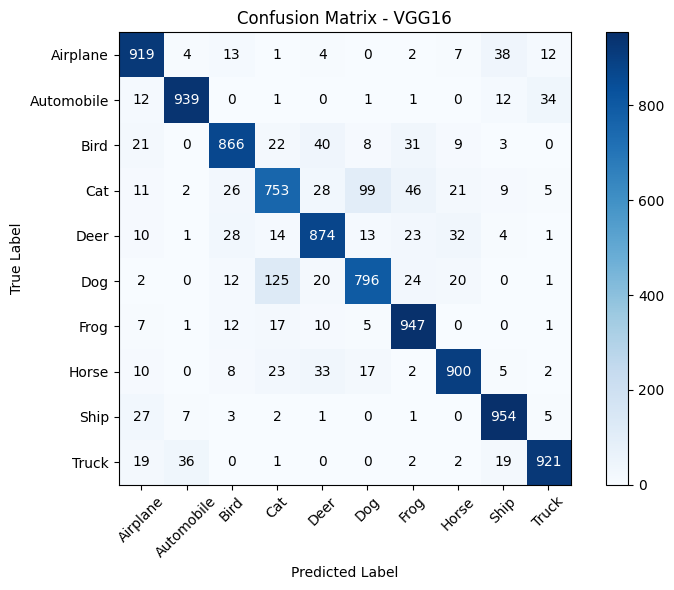

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title(f'Confusion Matrix - {BASE_MODEL_NAME}')
plt.colorbar()
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

In [16]:

acc_curve = history.history['accuracy'] + history_ft.history['accuracy']
val_acc_curve = history.history['val_accuracy'] + history_ft.history['val_accuracy']
loss_curve = history.history['loss'] + history_ft.history['loss']
val_loss_curve = history.history['val_loss'] + history_ft.history['val_loss']
ft_start = len(history.history['accuracy'])

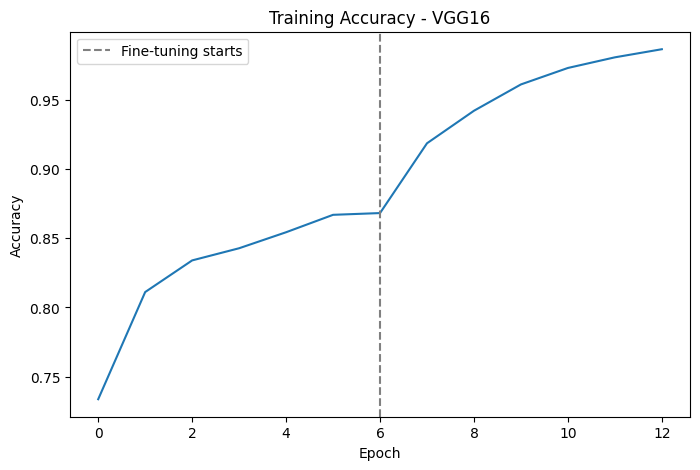

In [17]:
# 2. Training Accuracy
plt.figure(figsize=(8, 5))
plt.plot(acc_curve, color='tab:blue')
plt.axvline(x=ft_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title(f'Training Accuracy - {BASE_MODEL_NAME}')
plt.legend()
plt.savefig("training_accuracy.png")
plt.show()

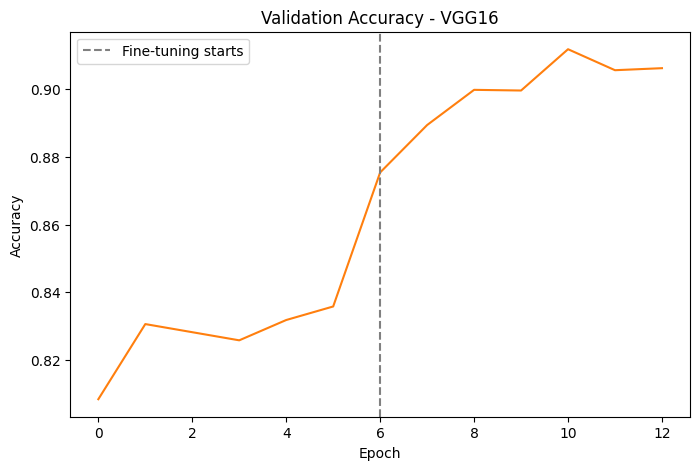

In [18]:
# 3. Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(val_acc_curve, color='tab:orange')
plt.axvline(x=ft_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title(f'Validation Accuracy - {BASE_MODEL_NAME}')
plt.legend()
plt.savefig("validation_accuracy.png")
plt.show()

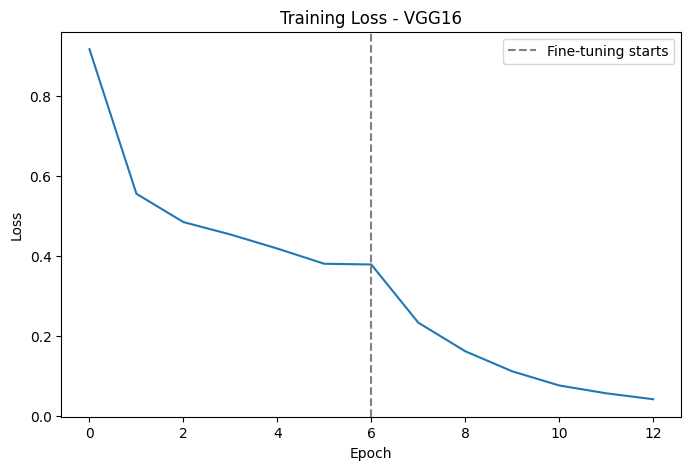

In [19]:

# 4. Training Loss
plt.figure(figsize=(8, 5))
plt.plot(loss_curve, color='tab:blue')
plt.axvline(x=ft_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title(f'Training Loss - {BASE_MODEL_NAME}')
plt.legend()
plt.savefig("training_loss.png")
plt.show()

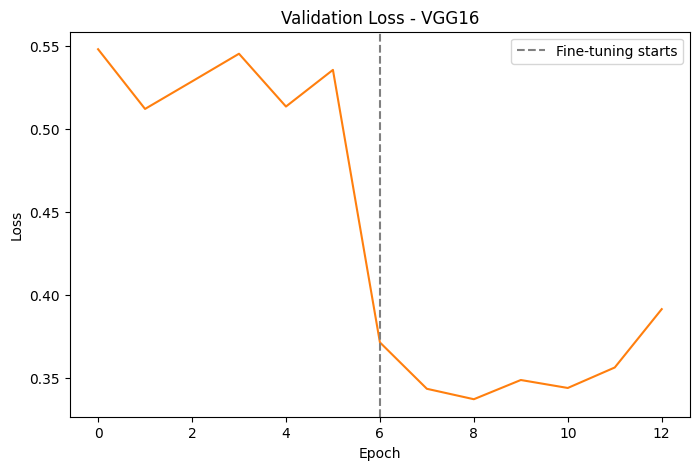

In [20]:
# 5. Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(val_loss_curve, color='tab:orange')
plt.axvline(x=ft_start, color='gray', linestyle='--', label='Fine-tuning starts')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title(f'Validation Loss - {BASE_MODEL_NAME}')
plt.legend()
plt.savefig("validation_loss.png")
plt.show()

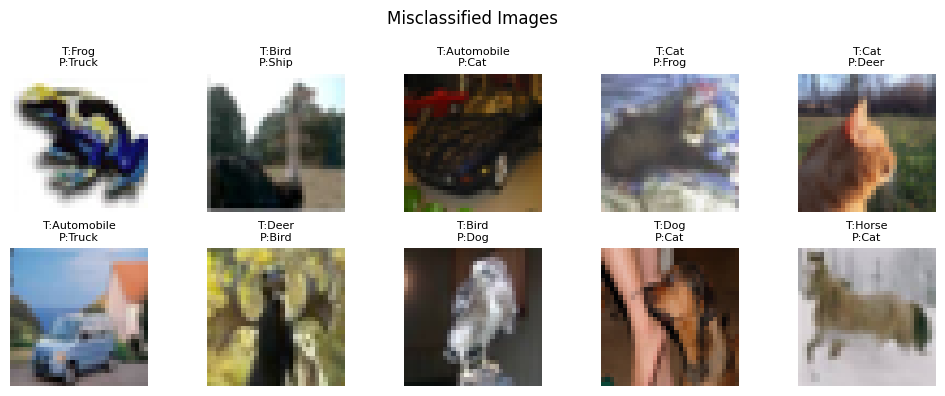

In [21]:
# 7. Misclassified images (optional)
misclassified_idx = np.where(y_pred != y_true)[0]
sample_idx = np.random.choice(misclassified_idx, size=min(10, len(misclassified_idx)), replace=False)

plt.figure(figsize=(10, 4))
for i, idx in enumerate(sample_idx):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}", fontsize=8)
    plt.axis('off')
plt.suptitle("Misclassified Images")
plt.tight_layout()
plt.savefig("misclassified_images.png")
plt.show()

In [22]:
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

print(f"Model                : {BASE_MODEL_NAME}")
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print(f"Training Accuracy    : {history_ft.history['accuracy'][-1]*100:.2f}%")
print(f"Testing Accuracy     : {post_ft_acc*100:.2f}%")
print(f"Precision            : {precision*100:.2f}%")
print(f"Recall               : {recall*100:.2f}%")
print(f"F1-score             : {f1*100:.2f}%")

Model                : VGG16
Total Parameters     : 14,848,586
Trainable Parameters : 7,213,322
Training Accuracy    : 98.68%
Testing Accuracy     : 88.69%
Precision            : 88.64%
Recall               : 88.69%
F1-score             : 88.63%


In [23]:
INPUT_SHAPE = (32, 32, 3)
BATCH_SIZE_SCRATCH = 32
EPOCHS_SCRATCH = 15

def build_lenet5():
    m = Sequential([
        Input(shape=INPUT_SHAPE),
        Conv2D(6, (5, 5), activation='tanh', padding='same'),
        AveragePooling2D((2, 2)),
        Conv2D(16, (5, 5), activation='tanh'),
        AveragePooling2D((2, 2)),
        Flatten(),
        Dense(120, activation='tanh'),
        Dense(84, activation='tanh'),
        Dense(num_classes, activation='softmax'),
    ], name='LeNet5')
    m.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_alexnet():
    # Scaled down to fit CIFAR-10's 32x32 input (original AlexNet used 227x227 images)
    m = Sequential([
        Input(shape=INPUT_SHAPE),
        Conv2D(96, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(384, (3, 3), activation='relu', padding='same'),
        Conv2D(384, (3, 3), activation='relu', padding='same'),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(1024, activation='relu'),
        Dropout(0.5),
        Dense(1024, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax'),
    ], name='AlexNet')
    m.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

scratch_results = {}
for name, builder in [('LeNet-5', build_lenet5), ('AlexNet', build_alexnet)]:
    print(f"\n{'='*50}\nTraining {name} from scratch\n{'='*50}")
    tf.keras.backend.clear_session()
    m = builder()
    early_stop_s = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

    start = time.time()
    m.fit(x_train, y_train_cat, validation_data=(x_val, y_val_cat),
          batch_size=BATCH_SIZE_SCRATCH, epochs=EPOCHS_SCRATCH,
          callbacks=[early_stop_s], verbose=1)
    elapsed = time.time() - start

    pred = np.argmax(m.predict(x_test, verbose=0), axis=1)
    scratch_results[name] = {
        'Model': name,
        'Parameters': f"{m.count_params():,}",
        'Accuracy (%)': round(accuracy_score(y_true, pred) * 100, 2),
        'Training Time': f"{elapsed/60:.1f} min"
    }
    print(f"{name}: acc={scratch_results[name]['Accuracy (%)']:.2f}%, time={elapsed:.1f}s")
    del m


Training LeNet-5 from scratch
Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.3753 - loss: 1.7716 - val_accuracy: 0.4270 - val_loss: 1.6498
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4546 - loss: 1.5401 - val_accuracy: 0.4778 - val_loss: 1.5044
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5000 - loss: 1.4076 - val_accuracy: 0.5018 - val_loss: 1.4220
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5253 - loss: 1.3347 - val_accuracy: 0.5164 - val_loss: 1.3703
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.5514 - loss: 1.2682 - val_accuracy: 0.5192 - val_loss: 1.3751
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5668 - loss: 1.2208 - val_accuracy: 0.5276 - val_loss: 1.3559
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5806 - loss: 1.1795 - val_accuracy: 0.5180 - val_loss: 1.3782
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - a

In [26]:
def run_transfer_pipeline(model_name, img_size=96, epochs=10, ft_epochs=5):
    """Builds, trains, fine-tunes and evaluates one pretrained architecture. Returns a results dict."""
    print(f"\n{'='*50}\nRunning transfer-learning pipeline for: {model_name}\n{'='*50}")

    tf.keras.backend.clear_session()
    base, preprocess = get_base_model(model_name, (img_size, img_size, 3))
    base.trainable = False

    inputs_i = Input(shape=(32, 32, 3))
    xi = Lambda(lambda img: tf.image.resize(img, (img_size, img_size)))(inputs_i)
    xi = Lambda(lambda img: img * 255.0)(xi)
    xi = Lambda(preprocess)(xi)
    xi = base(xi, training=False)
    xi = GlobalAveragePooling2D()(xi)
    xi = Dense(256, activation='relu')(xi)
    xi = Dropout(0.3)(xi)
    outputs_i = Dense(num_classes, activation='softmax')(xi)
    model_i = Model(inputs_i, outputs_i)

    model_i.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])

    early_stop_i = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

    start_time = time.time()

    model_i.fit(x_train, y_train_cat, validation_data=(x_val, y_val_cat),
                batch_size=32, epochs=epochs, callbacks=[early_stop_i], verbose=1)

    base.trainable = True
    fine_tune_at = int(len(base.layers) * 0.8)
    for layer in base.layers[:fine_tune_at]:
        layer.trainable = False

    model_i.compile(optimizer=Adam(learning_rate=1e-5),
                     loss='categorical_crossentropy', metrics=['accuracy'])

    model_i.fit(x_train, y_train_cat, validation_data=(x_val, y_val_cat),
                batch_size=32, epochs=ft_epochs, callbacks=[early_stop_i], verbose=1)

    elapsed = time.time() - start_time

    test_loss, test_acc = model_i.evaluate(x_test, y_test_cat, verbose=0)

    result = {
        'Model': model_name,
        'Parameters': f"{model_i.count_params():,}",
        'Accuracy (%)': round(test_acc * 100, 2),
        'Training Time': f"{elapsed/60:.1f} min"
    }
    del model_i
    return result

In [28]:
transfer_results = {}

In [29]:
transfer_results['GoogleNet (InceptionV3)'] = run_transfer_pipeline('InceptionV3', epochs=10, ft_epochs=5)


Running transfer-learning pipeline for: InceptionV3
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 38ms/step - accuracy: 0.6120 - loss: 1.1491 - val_accuracy: 0.6668 - val_loss: 0.9449
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.6764 - loss: 0.9337 - val_accuracy: 0.6890 - val_loss: 0.8816
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.6999 - loss: 0.8644 - val_accuracy: 0.7060 - val_loss: 0.8521
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - accuracy: 0.7169 - loss: 0.8076 - val_accuracy: 0.6956 - val_loss: 0.8685
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.7276 - loss: 0.7715 - val_accuracy: 0.7054 - val_loss: 0.8584
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.7436 - loss: 0.7226 - val_accuracy: 0.7046 - val_loss: 0.8627
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.7560 - loss: 0.6905 - val_accuracy: 0.7138 - val_loss: 0.8617
Epoch 1/5
1407/1407 ━━━

In [35]:
transfer_results['ResNet50'] = run_transfer_pipeline('ResNet50', epochs=10, ft_epochs=5)


Running transfer-learning pipeline for: ResNet50
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 60s 34ms/step - accuracy: 0.8000 - loss: 0.6027 - val_accuracy: 0.8400 - val_loss: 0.4357
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.8474 - loss: 0.4485 - val_accuracy: 0.8560 - val_loss: 0.4374
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.8605 - loss: 0.3995 - val_accuracy: 0.8614 - val_loss: 0.4047
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.8749 - loss: 0.3581 - val_accuracy: 0.8562 - val_loss: 0.4188
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.8845 - loss: 0.3281 - val_accuracy: 0.8606 - val_loss: 0.4247
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.8948 - loss: 0.2962 - val_accuracy: 0.8566 - val_loss: 0.4537
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 24ms/step - accuracy: 0.9018 - loss: 0.2753 - val_accuracy: 0.8736 - val_loss: 0.4134
Epoch 1/5
1407/1407 ━━━━━━

In [36]:
# Build the final Section 18.2 comparison table
all_results = [
    scratch_results['LeNet-5'],
    scratch_results['AlexNet'],
    transfer_results['GoogleNet (InceptionV3)'],
    transfer_results['ResNet50'],
]

results_df = pd.DataFrame(all_results)
print(results_df.to_string(index=False))
results_df.to_csv('cnn_comparison_results.csv', index=False)

      Model Parameters  Accuracy (%) Training Time
    LeNet-5     83,126         52.73       1.6 min
    AlexNet  8,578,314         73.17       6.5 min
InceptionV3 22,329,898         76.66       7.7 min
   ResNet50 24,114,826         89.21      10.0 min


In [41]:
# ============================================================
# TASK 6: HYPERPARAMETER STUDY
# ============================================================

def build_and_train(
    lr=0.001,
    batch_size=32,
    epochs=10,
    optimizer_name='Adam',
    dense_units=256,
    freeze='All',
    base_name=BASE_MODEL_NAME,
    img_size=IMG_SIZE
):

    print(f"\n{'='*60}")
    print("Hyperparameter Configuration")
    print(f"Learning Rate : {lr}")
    print(f"Batch Size    : {batch_size}")
    print(f"Epochs        : {epochs}")
    print(f"Optimizer     : {optimizer_name}")
    print(f"Dense Units   : {dense_units}")
    print(f"Frozen Layers : {freeze}")
    print(f"{'='*60}")

    # Clear previous model from memory
    tf.keras.backend.clear_session()

    # --------------------------------------------------------
    # 1. Load pretrained model
    # --------------------------------------------------------
    base, preprocess = get_base_model(
        base_name,
        (img_size, img_size, 3)
    )

    # --------------------------------------------------------
    # 2. Freeze / partially freeze convolutional base
    # --------------------------------------------------------
    if freeze == 'All':
        base.trainable = False

    elif freeze == 'Partial':
        base.trainable = True

        # Freeze first 80%, train last 20%
        fine_tune_at = int(len(base.layers) * 0.8)

        for layer in base.layers[:fine_tune_at]:
            layer.trainable = False

        for layer in base.layers[fine_tune_at:]:
            layer.trainable = True

    # --------------------------------------------------------
    # 3. Build transfer learning model
    # --------------------------------------------------------
    inputs = Input(shape=(32, 32, 3))

    # Resize CIFAR-10 images
    x = Lambda(
        lambda img: tf.image.resize(img, (img_size, img_size))
    )(inputs)

    # Convert [0,1] back to [0,255]
    x = Lambda(
        lambda img: img * 255.0
    )(x)

    # Pretrained model preprocessing
    x = Lambda(preprocess)(x)

    # Pretrained CNN
    x = base(x, training=(freeze == 'Partial'))

    # Global Average Pooling
    x = GlobalAveragePooling2D()(x)

    # Dense layer
    x = Dense(
        dense_units,
        activation='relu'
    )(x)

    # Dropout
    x = Dropout(0.3)(x)

    # Output layer
    outputs = Dense(
        num_classes,
        activation='softmax'
    )(x)

    model_hp = Model(inputs, outputs)

    # --------------------------------------------------------
    # 4. Select optimizer
    # --------------------------------------------------------
    if optimizer_name == 'Adam':
        optimizer = Adam(learning_rate=lr)

    elif optimizer_name == 'SGD':
        optimizer = SGD(
            learning_rate=lr,
            momentum=0.9
        )

    # --------------------------------------------------------
    # 5. Compile
    # --------------------------------------------------------
    model_hp.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # --------------------------------------------------------
    # 6. Train
    # --------------------------------------------------------
    start_time = time.time()

    history_hp = model_hp.fit(
        x_train,
        y_train_cat,
        validation_data=(x_val, y_val_cat),
        batch_size=batch_size,
        epochs=epochs,
        verbose=1
    )

    training_time = time.time() - start_time

    # --------------------------------------------------------
    # 7. Evaluate on TEST set
    # --------------------------------------------------------
    test_loss, test_acc = model_hp.evaluate(
        x_test,
        y_test_cat,
        verbose=0
    )

    # --------------------------------------------------------
    # 8. Best validation accuracy
    # --------------------------------------------------------
    best_val_acc = max(
        history_hp.history['val_accuracy']
    )

    # --------------------------------------------------------
    # 9. Final training accuracy
    # --------------------------------------------------------
    final_train_acc = history_hp.history['accuracy'][-1]

    # --------------------------------------------------------
    # 10. Parameter counts
    # --------------------------------------------------------
    total_params = model_hp.count_params()

    trainable_params = np.sum([
        np.prod(w.shape)
        for w in model_hp.trainable_weights
    ])

    # --------------------------------------------------------
    # 11. Store results
    # --------------------------------------------------------
    result = {
        'Learning Rate': lr,
        'Batch Size': batch_size,
        'Epochs': epochs,
        'Optimizer': optimizer_name,
        'Dense Units': dense_units,
        'Frozen Layers': freeze,
        'Training Accuracy (%)': round(final_train_acc * 100, 2),
        'Best Validation Accuracy (%)': round(best_val_acc * 100, 2),
        'Testing Accuracy (%)': round(test_acc * 100, 2),
        'Training Time (min)': round(training_time / 60, 2),
        'Total Parameters': total_params,
        'Trainable Parameters': int(trainable_params)
    }

    # --------------------------------------------------------
    # 12. Print result
    # --------------------------------------------------------
    print("\nResult:")
    for key, value in result.items():
        print(f"{key}: {value}")

    del model_hp
    del base

    return result

In [42]:
# ============================================================
# HYPERPARAMETER CONFIGURATIONS
# ============================================================

baseline = {
    'lr': 0.001,
    'batch_size': 32,
    'epochs': 10,
    'optimizer_name': 'Adam',
    'dense_units': 256,
    'freeze': 'All'
}

configs = [

    # 1. Baseline
    {
        **baseline
    },

    # 2. Learning Rate = 0.0001
    {
        **baseline,
        'lr': 0.0001
    },

    # 3. Batch Size = 16
    {
        **baseline,
        'batch_size': 16
    },

    # 4. Batch Size = 64
    {
        **baseline,
        'batch_size': 64
    },

    # 5. Epochs = 20
    {
        **baseline,
        'epochs': 20
    },

    # 6. Optimizer = SGD
    {
        **baseline,
        'optimizer_name': 'SGD'
    },

    # 7. Dense Units = 128
    {
        **baseline,
        'dense_units': 128
    },

    # 8. Frozen Layers = Partial
    {
        **baseline,
        'freeze': 'Partial'
    }
]

print("Total Hyperparameter Experiments:", len(configs))

for i, cfg in enumerate(configs, 1):
    print(f"\nExperiment {i}:")
    print(cfg)

Total Hyperparameter Experiments: 8

Experiment 1:
{'lr': 0.001, 'batch_size': 32, 'epochs': 10, 'optimizer_name': 'Adam', 'dense_units': 256, 'freeze': 'All'}

Experiment 2:
{'lr': 0.0001, 'batch_size': 32, 'epochs': 10, 'optimizer_name': 'Adam', 'dense_units': 256, 'freeze': 'All'}

Experiment 3:
{'lr': 0.001, 'batch_size': 16, 'epochs': 10, 'optimizer_name': 'Adam', 'dense_units': 256, 'freeze': 'All'}

Experiment 4:
{'lr': 0.001, 'batch_size': 64, 'epochs': 10, 'optimizer_name': 'Adam', 'dense_units': 256, 'freeze': 'All'}

Experiment 5:
{'lr': 0.001, 'batch_size': 32, 'epochs': 20, 'optimizer_name': 'Adam', 'dense_units': 256, 'freeze': 'All'}

Experiment 6:
{'lr': 0.001, 'batch_size': 32, 'epochs': 10, 'optimizer_name': 'SGD', 'dense_units': 256, 'freeze': 'All'}

Experiment 7:
{'lr': 0.001, 'batch_size': 32, 'epochs': 10, 'optimizer_name': 'Adam', 'dense_units': 128, 'freeze': 'All'}

Experiment 8:
{'lr': 0.001, 'batch_size': 32, 'epochs': 10, 'optimizer_name': 'Adam', 'dense_un

In [43]:
# ============================================================
# RUN HYPERPARAMETER STUDY
# ============================================================

hp_results = []

for i, cfg in enumerate(configs, 1):

    print("\n")

    print(f"RUN {i}/{len(configs)}")


    result = build_and_train(**cfg)

    hp_results.append(result)


# ============================================================
# CREATE RESULTS DATAFRAME
# ============================================================

hp_results_df = pd.DataFrame(hp_results)

print("\n")
print("=" * 100)
print("HYPERPARAMETER STUDY RESULTS")
print("=" * 100)

display(hp_results_df)


# ============================================================
# SAVE RESULTS
# ============================================================

hp_results_df.to_csv(
    "hyperparameter_results.csv",
    index=False
)

print("\nResults saved as: hyperparameter_results.csv")



RUN 1/8

Hyperparameter Configuration
Learning Rate : 0.001
Batch Size    : 32
Epochs        : 10
Optimizer     : Adam
Dense Units   : 256
Frozen Layers : All
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 47ms/step - accuracy: 0.7365 - loss: 0.8918 - val_accuracy: 0.8136 - val_loss: 0.5465
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 49ms/step - accuracy: 0.8112 - loss: 0.5579 - val_accuracy: 0.8202 - val_loss: 0.5323
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 50ms/step - accuracy: 0.8288 - loss: 0.4928 - val_accuracy: 0.8280 - val_loss: 0.5116
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 49ms/step - accuracy: 0.8418 - loss: 0.4554 - val_accuracy: 0.8278 - val_loss: 0.5009
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 49ms/step - accuracy: 0.8545 - loss: 0.4163 - val_accuracy: 0.8310 - val_loss: 0.5200
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 49ms/step - accuracy: 0.8654 - loss: 0.3877 - val_accuracy: 0.8320 - val_loss: 0.5347
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 4

,Learning Rate,Batch Size,Epochs,Optimizer,Dense Units,Frozen Layers,Training Accuracy (%),Best Validation Accuracy (%),Testing Accuracy (%),Training Time (min),Total Parameters,Trainable Parameters
0,0.0010,32,10,Adam,256,All,89.45,83.42,83.31,11.61,14848586,133898
1,0.0001,32,10,Adam,256,All,87.50,83.44,82.75,11.70,14848586,133898
2,0.0010,16,10,Adam,256,All,87.80,83.26,82.63,12.31,14848586,133898
3,0.0010,64,10,Adam,256,All,90.95,84.04,83.65,11.78,14848586,133898
4,0.0010,32,20,Adam,256,All,93.28,83.54,82.44,23.07,14848586,133898
5,0.0010,32,10,SGD,256,All,87.42,83.74,82.50,11.63,14848586,133898
6,0.0010,32,10,Adam,128,All,87.08,83.38,82.69,11.60,14781642,66954
7,0.0010,32,10,Adam,256,Partial,9.89,10.00,10.00,15.40,14848586,7213322



Results saved as: hyperparameter_results.csv


In [46]:

best_idx = hp_results_df[
    'Testing Accuracy (%)'
].idxmax()

best_config = hp_results_df.loc[best_idx]

print("BEST HYPERPARAMETER CONFIGURATION")
print("=" * 50)

print(best_config.to_string())

BEST HYPERPARAMETER CONFIGURATION
Learning Rate                      0.001
Batch Size                            64
Epochs                                10
Optimizer                           Adam
Dense Units                          256
Frozen Layers                        All
Training Accuracy (%)              90.95
Best Validation Accuracy (%)       84.04
Testing Accuracy (%)               83.65
Training Time (min)                11.78
Total Parameters                14848586
Trainable Parameters              133898
